# Project Setup

This is a personal project by Bryan Beus -- https://bluesanta.io -- to explore effective and ineffective Kickstarter campaigns, with regards to data analytics and machine learning.

In this particular notebook, we'll import our visualized dataset, prepare the data for modeling, and then create predictive models.

## Library Imports

In [1]:
# Common DataFrame Tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Python Libraries
from datetime import datetime
import json
from wordcloud import WordCloud, STOPWORDS

In [2]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

# Logistic Regression set
from sklearn.preprocessing import OneHotEncoder as OHE
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#
# GridSearchCV
from sklearn import svm
from sklearn.model_selection import GridSearchCV
#
print("Loaded Libraries")

Loaded Libraries


## DataFrame Import

In [3]:
df = pd.read_parquet('../../metadata/02-ksr-metadata.parquet', engine='pyarrow')

In [4]:
df.head()

,id,name,blurb,goal,pledged,state,slug,country,country_displayable_name,currency,...,category.name,category.analytics_name,category.slug,category.position,category.parent_id,category.parent_name,category.color,urls.web.project,creator.is_ksr_admin,relevant_category
0,1703332404,Massage By Donation... Seriously!,Physical wellness is not a luxury; it is a nec...,53170.0,52.0,failed,massage-by-donation-seriously,US,the United States,USD,...,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/pressurem...,False,1.0
1,1704943227,eifel-abenteuer.de - Nachhaltige Outdoorangebo...,Aufbau eines erlebnispädagogischen Outdoorakti...,10000.0,0.0,failed,eifel-abenteuerde-nachhaltige-outdoorangebote-...,DE,Germany,EUR,...,Live Games,Live Games,games/live games,2,12.0,Games,51627,https://www.kickstarter.com/projects/eifel-abe...,False,12.0
2,150178599,"Graphic Novel ""Pachacuti""","Graphic Novel cruda e intensa, narrata in uno ...",2500.0,34.0,failed,graphic-novel-pachacuti,IT,Italy,EUR,...,Graphic Novels,Graphic Novels,comics/graphic novels,4,3.0,Comics,16776056,https://www.kickstarter.com/projects/pacachuti...,False,3.0
3,699875365,MadeInTuskegee: Pop-Up Shops and Open-Air Cour...,Help Fund Our Renovation: Transforming a Histo...,150537.0,210.0,failed,madeintuskegee-pop-up-shops-and-open-air-court...,US,the United States,USD,...,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/madeintus...,False,1.0
4,739499553,Goddesses in Everywoman,A guided multimedia self-discovery journey,3900.0,0.0,failed,goddesses-in-everywoman,US,the United States,USD,...,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/lolacarne...,False,1.0


# Preprocessing

## Dropping Unnecessary Columns

Several columns are useful for identification and other purposes, but are not appropriate for modeling.

We create a dataframe with a reduced number of columns, keeping only those that are necessary for the model.

Our target for predictive modeling is the `state` column, keeping only `successful` and `failed` values.

We drop all of the `pledged` related columns, because, even though they are not our target, they are  

In [5]:
# Keep the 'id' column as the index so that we can use it for identification purposes 
df = df.set_index('id')

In [6]:
df.columns

Index(['name', 'blurb', 'goal', 'pledged', 'state', 'slug', 'country',
       'country_displayable_name', 'currency', 'currency_symbol',
       'currency_trailing_code', 'deadline', 'state_changed_at', 'created_at',
       'launched_at', 'staff_pick', 'backers_count', 'static_usd_rate',
       'usd_pledged', 'converted_pledged_amount', 'fx_rate',
       'usd_exchange_rate', 'current_currency', 'usd_type', 'percent_funded',
       'creator.id', 'creator.name', 'creator.has_admin_message_badge',
       'creator.partner_badge', 'creator.ppo_has_action',
       'creator.backing_action_count', 'location.id', 'location.name',
       'location.short_name', 'location.displayable_name',
       'location.localized_name', 'location.country', 'location.state',
       'location.type', 'location.expanded_country', 'category.id',
       'category.name', 'category.analytics_name', 'category.slug',
       'category.position', 'category.parent_id', 'category.parent_name',
       'category.color', 'urls.

In [7]:
# If not done previously, create a converted_goal_amount column
df['converted_goal_amount'] = df['goal'] * df['static_usd_rate']

Drop all the columns that are not an appropriate fit for our model.

In [8]:
dfm = df.drop(columns=[
    'name',
    'blurb',
    'slug',
    'goal',
    'pledged',
    'country_displayable_name',
    'currency_symbol',
    'currency_trailing_code',
    'deadline',
    'state_changed_at',
    'created_at',
    'launched_at',
    'static_usd_rate',
    'usd_pledged',
    'converted_pledged_amount', 
    'fx_rate',
    'usd_exchange_rate',
    'current_currency',
    'usd_type',
    'percent_funded',
    'creator.id',
    'creator.name',
    'creator.ppo_has_action',
    'location.id',
    'location.name',
    'location.short_name',
    'location.displayable_name',
    'location.localized_name',
    'location.country',
    'location.state',
    'location.type',
    'location.expanded_country',
    'category.id',
    'category.name',
    'category.analytics_name',
    'category.slug',
    'category.position',
    'category.parent_name',
    'category.parent_id',
    'category.color',
    'urls.web.project',
    'creator.is_ksr_admin'
])

In [9]:
dfm.head()

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,
1703332404,failed,US,USD,False,3,False,False,0,1.0,53170.0000
1704943227,failed,DE,EUR,False,0,False,False,0,12.0,10302.7250
150178599,failed,IT,EUR,False,2,False,False,0,3.0,2578.8137
699875365,failed,US,USD,False,3,False,False,0,1.0,150537.0000
739499553,failed,US,USD,False,0,False,False,0,1.0,3900.0000


In [10]:
# Drop any 'cancelled' or other outcomes as we only want to focus on successful or failed projects
dfm = dfm[(dfm['state'] == 'successful') | (dfm['state'] == 'failed')]

Let's check and see if the admin/partner badge columns have any value. 

In [11]:
dfm.sort_values(by='creator.has_admin_message_badge', ascending=False)

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,
1703332404,failed,US,USD,False,3,False,False,0,1.0,53170.000000
1476755569,successful,GB,GBP,True,264,False,False,0,18.0,251.880604
1020709194,successful,US,USD,False,144,False,False,0,18.0,7500.000000
21274643,successful,US,USD,True,180,False,False,0,18.0,10000.000000
2079810328,successful,US,USD,False,52,False,False,0,18.0,2500.000000
...,...,...,...,...,...,...,...,...,...,...
590059957,successful,IE,EUR,False,15,False,False,0,14.0,5247.773650
1814098243,successful,IT,EUR,False,66,False,False,0,14.0,1882.242720
799085709,successful,GB,GBP,False,244,False,False,0,14.0,11338.068420


In [12]:
dfm['creator.has_admin_message_badge'].value_counts()

creator.has_admin_message_badge
False    86514
Name: count, dtype: int64

There are  no admin message badges at this point. This column can go.

In [13]:
dfm['creator.partner_badge'].value_counts()

creator.partner_badge
False    86496
True        18
Name: count, dtype: int64

There is some variety here. However, do partners automatically succeed?

In [14]:
dfm[(dfm['creator.partner_badge'] == True) & (dfm['state'] == 'failed')].head()

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,


This appears to be the case. Partners essentially always win.

There's really no need to include this aspect in our model.

In [15]:
dfm = dfm.drop(columns=['creator.has_admin_message_badge', 'creator.partner_badge'])

In [16]:
dfm.head()

,state,country,currency,staff_pick,backers_count,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,
1703332404,failed,US,USD,False,3,0,1.0,53170.0000
1704943227,failed,DE,EUR,False,0,0,12.0,10302.7250
150178599,failed,IT,EUR,False,2,0,3.0,2578.8137
699875365,failed,US,USD,False,3,0,1.0,150537.0000
739499553,failed,US,USD,False,0,0,1.0,3900.0000


In [17]:
dfm.shape

(86514, 8)

At this point, we have our columns narrowed down to the simplest features.

We are prepared to create a model that attempts to predict a binary outcome: 'success' or 'failure'.

We can also later come back, add back in the `converted_pledged_amount` column, drop all the `failed` rows, and with the `successful` rows create a linear regression model that predicts the variable level of success given a similar set of independent features.

## Creating Dummy Variables

We create our dummy variables for our categorical columns.

We convert the `state` column into binary `0` and `1` values for regression purposes.

In [18]:
def convert_state_binary(x):
    if x == 'successful':
        return 1
    else:
        return 0
dfm['state_adj'] = dfm['state'].apply(convert_state_binary)

In [25]:
class_counts = dfm['state_adj'].value_counts()
class_counts

state_adj
1    55856
0    30658
Name: count, dtype: int64

In [20]:
def convert_staff_binary(x):
    if x == True:
        return 1
    else:
        return 0

In [21]:
dfm = dfm.drop(columns=['state'])

In [22]:
df_d = pd.get_dummies(dfm, columns=['country', 'currency', 'relevant_category'], prefix='c')

In [23]:
df_d.columns = df_d.columns.astype(str)

In [24]:
df_d.head()

,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,state_adj,c_AT,c_AU,c_BE,c_CA,c_CH,...,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0
id,,,,,,,,,,,,,,,,,,,,,
1703332404,False,3,0,53170.0000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1704943227,False,0,0,10302.7250,0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
150178599,False,2,0,2578.8137,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
699875365,False,3,0,150537.0000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
739499553,False,0,0,3900.0000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Calculating Target Feature Balance

In [26]:
class_percentages = pd.Series([(x / df_d.shape[0]) * 100.00 for x in class_counts])
class_percentages

0    64.562961
1    35.437039
dtype: float64

We use the percentages as labels and plot the distribution.

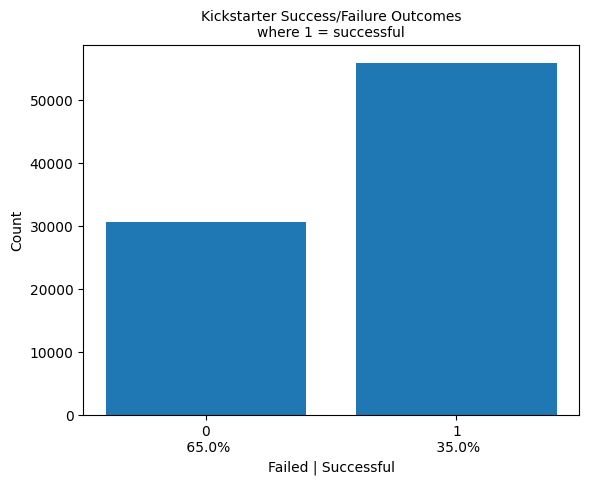

In [30]:
fig, ax = plt.subplots()
ax.bar(class_counts.index, class_counts)
ax.set_xticks([0, 1])
ax.set_xticklabels(class_percentages.index.astype(str) + '\n' + ' ' +
                   class_percentages.round(0).astype(str) + '%')
ax.set_ylabel('Count')
ax.set_xlabel('Failed | Successful')
ax.set_title('Kickstarter Success/Failure Outcomes\nwhere 1 = successful',
              fontsize = 10)
plt.show()

## Train Test Split

## Building a Model with Only Two Features

By way of exploration, let's build a model using only two features. We'll use `converted_goal_amount` and `backers_count` as our two features. 

These two features are useful, because an experienced businessman can create a reasonably useful guess at how many people will support their campaign based on customer activity, and the businessman can arbitrarily determine their stated goal. 

We divide the data into training and test sets.

In [33]:
X = pd.DataFrame(df_d[['converted_goal_amount', 'backers_count']])
y = pd.DataFrame(df_d['state_adj'])

In [34]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,
                                                y,
                                                train_size = 0.75,
                                                random_state = 42)